In [3]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Resolve directories relative to this notebook (../data/*)
NOTEBOOK_DIR = Path.cwd()
RAW_DIR = (NOTEBOOK_DIR / ".." / "data" / "raw").resolve()
PROCESSED_DIR = (NOTEBOOK_DIR / ".." / "data" / "processed").resolve()

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01), with a slight shift before May 2022
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0]
    if idx.size > 0:
        returns[idx[0]] = v

# Column 2: correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = RAW_DIR / "outliers_homework.csv"
if not csv_path.exists():
    df.to_csv(csv_path, index=False)
    print(f"Synthetic dataset created at: {csv_path}")
else:
    print(f"File already exists at: {csv_path} — skipping creation.")


File already exists at: C:\Users\User\bootcamp_Khushi_Khanna\homework\homework7\data\raw\outliers_homework.csv — skipping creation.


In [4]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

CWD = pathlib.Path.cwd()
ROOT = CWD if (CWD / "src").exists() else CWD.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series
import numpy as np, pandas as pd, matplotlib.pyplot as plt

RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)




In [5]:
csv_path = RAW_DIR / "outliers_homework.csv"
df = pd.read_csv(csv_path, parse_dates=["date"])
df.head()


,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


In [6]:
target_col = "daily_return"
mask_iqr, lo, hi = detect_outliers_iqr(df[target_col], k=1.5)
mask_z, zscores = detect_outliers_zscore(df[target_col], threshold=3.0)

df[f"{target_col}_outlier_iqr"] = mask_iqr
df[f"{target_col}_outlier_z"]   = mask_z

df[[target_col, f"{target_col}_outlier_iqr", f"{target_col}_outlier_z"]].head()


,daily_return,daily_return_outlier_iqr,daily_return_outlier_z
0,0.001263,False,False
1,-0.020046,False,False
2,0.004739,False,False
3,0.009953,False,False
4,0.008872,False,False


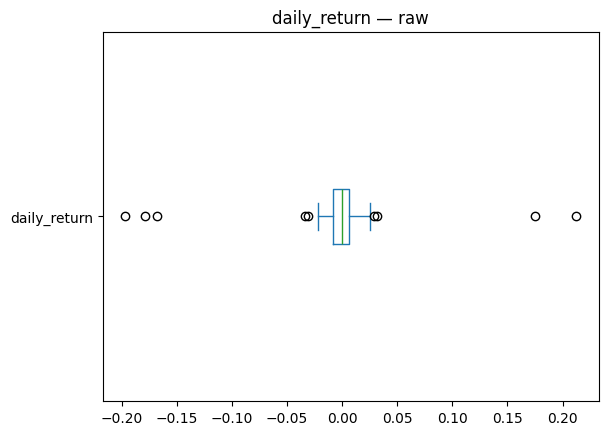

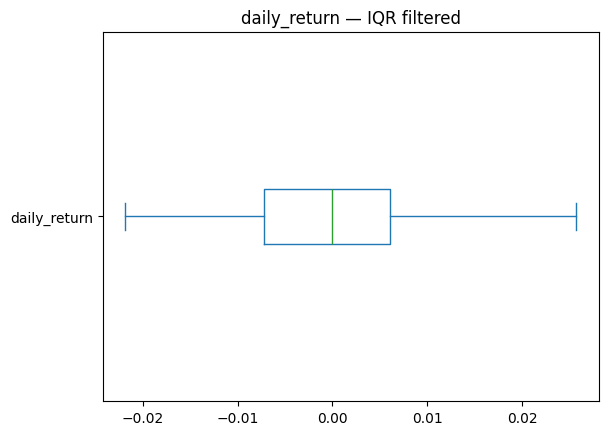

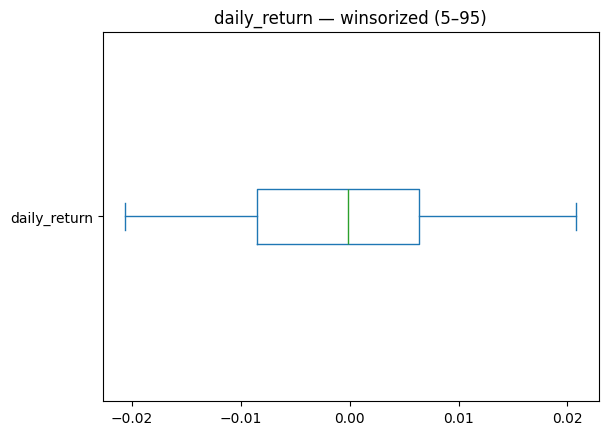

In [9]:
plt.figure()
df[target_col].plot(kind="box", vert=False)
plt.title(f"{target_col} — raw")
plt.show()

plt.figure()
df.loc[~mask_iqr, target_col].plot(kind="box", vert=False)
plt.title(f"{target_col} — IQR filtered")
plt.show()

wins = winsorize_series(df[target_col], 0.05, 0.95)
plt.figure()
wins.plot(kind="box", vert=False)
plt.title(f"{target_col} — winsorized (5–95)")
plt.show()


In [11]:
def summarize(s: pd.Series) -> dict:
    return {
        "count": int(s.count()),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std(ddof=0)),
        "min": float(s.min()),
        "max": float(s.max()),
    }

raw = df[target_col]
iqr_filtered = df.loc[~mask_iqr, target_col]
z_filtered   = df.loc[~mask_z,   target_col]
wins         = winsorize_series(raw, 0.05, 0.95)

summary = pd.DataFrame.from_dict({
    "Raw": summarize(raw),
    "IQR filtered": summarize(iqr_filtered),
    "Z filtered": summarize(z_filtered),
    "Winsorized (5–95)": summarize(wins),
}, orient="index")


display(summary)

summary_path = PROC_DIR / f"s07_summary_{target_col}.csv"
summary.to_csv(summary_path)
print(f"Saved summary table to: {summary_path}")


,count,mean,median,std,min,max
Raw,115,-0.001434,-0.000187,0.040402,-0.196672,0.212402
IQR filtered,106,-0.000039,-0.000100,0.009398,-0.021860,0.025708
Z filtered,110,-0.000078,-0.000100,0.011009,-0.033999,0.031952
Winsorized (5–95),115,-0.000251,-0.000187,0.010577,-0.020590,0.020797


Saved summary table to: C:\Users\User\bootcamp_Khushi_Khanna\homework\homework7\data\processed\s07_summary_daily_return.csv


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

x_name, y_name = "daily_return", "daily_return_2"

def fit_eval(x: pd.Series, y: pd.Series, label: str) -> dict:
    X = x.values.reshape(-1, 1)
    model = LinearRegression().fit(X, y.values)
    pred = model.predict(X)
    return {
        "label": label,
        "coef": float(model.coef_[0]),
        "intercept": float(model.intercept_),
        "r2": float(r2_score(y, pred)),
        "mae": float(mean_absolute_error(y, pred)),
        "n": int(len(y)),
    }

rows = [
    fit_eval(df[x_name], df[y_name], "Raw"),
    fit_eval(df.loc[~mask_iqr, x_name], df.loc[~mask_iqr, y_name], "IQR filtered"),
    fit_eval(df.loc[~mask_z,   x_name], df.loc[~mask_z,   y_name], "Z filtered"),
    fit_eval(df[x_name], winsorize_series(df[y_name], 0.05, 0.95), "Winsorized (Y 5–95)"),
]

model_compare = pd.DataFrame(rows)


display(model_compare)


mc_path = PROC_DIR / f"s07_model_compare_{x_name}_to_{y_name}.csv"
model_compare.to_csv(mc_path, index=False)
print(f"Saved regression comparison to: {mc_path}")


,label,coef,intercept,r2,mae,n
0,Raw,0.605869,0.000201,0.961859,0.003951,115
1,IQR filtered,0.589679,-0.000049,0.573566,0.003851,106
2,Z filtered,0.630315,-0.000088,0.679331,0.003848,110
3,Winsorized (Y 5–95),0.118781,-0.000010,0.336244,0.005391,115


Saved regression comparison to: C:\Users\User\bootcamp_Khushi_Khanna\homework\homework7\data\processed\s07_model_compare_daily_return_to_daily_return_2.csv


##  Methods, Assumptions, Risks

**Methods & thresholds chosen**:
- IQR rule with *k = 1.5* to flag outliers.  
- Z-score method with threshold = 3.0.  
- Winsorizing at 5%/95% quantiles to cap extremes.  

**Why chosen:**  
- IQR is robust against skewed data and doesnot assume normality.  
- Z-score is a standard rule of thumb when data is approximately normal.  
- Winsorizing keeps all rows but limits the influence of shocks.  

**Observed impacts:**  
- **Raw data:** Strong linear fit (Rsq ~ 0.96, slope 0.61), but heavily influenced by extreme May shocks.  
- **IQR filtered:** Rsq  dropped to 0.57; slope 0.59. Outliers were driving much of the correlation.  
- **Z filtered:** Slope 0.63, Rsq ~ 0.68. A balance between removing extremes and retaining structure.  
- **Winsorized:** Slope collapsed (0.12), Rsq ~0.34, MAE worsened too aggressive for the dataset.  

**Assumptions:**  
- May shocks are not normal daily returns but anomalies.  
- The relationship between daily_return and daily_return_2 is linear.  
- Thresholds (1.5 IQR, 3.0 Z) are appropriate rules of thumb.  

**Risks if assumptions are wrong:**  
- If shocks represent genuine market risk, removing/capping them underestimates tail risk.  
- If returns are naturally heavy-tailed, these rules may remove valid points.  
- Winsorizing can bias analysis by flattening real volatility.  

**Decision:**  
- Z filtering is a good compromise: less distortion than Raw but still preserves signal.  
- I would report both Raw and Z-filtered results.  
- Winsorizing not recommended as it disturbed the correlation
